In [1]:
import numpy as np
import galsim
from galsim import roman
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm, CenteredNorm
from copy import deepcopy
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.time import Time

import mejiro
from mejiro.galaxy_galaxy import Sample1, Sample2, SampleGG
from mejiro.synthetic_image import SyntheticImage
from mejiro.exposure import Exposure
from mejiro.instruments.roman import Roman
from mejiro.engines.stpsf_engine import STPSFEngine
from mejiro.engines.romanisim_engine import RomanISimEngine
from mejiro.utils import util

In [2]:
# Where to place it (pixel coords in the full 4088×4088 frame)
inject_x, inject_y = 2044, 2044
detector_position = (inject_x, inject_y)

# ── Observation parameters ──────────────────────────────────────────────
band = 'F129'
sca            = 1                 # WFI01
ma_table_number = 4
date           = "2027-01-01T00:00:00"
coord          = SkyCoord(ra=270.0 * u.deg, dec=66.0 * u.deg)

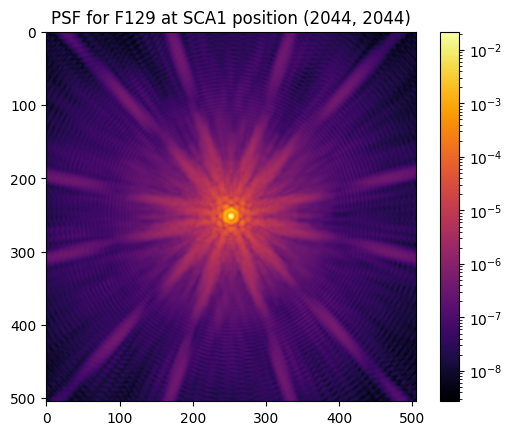

In [4]:
psf_cache_dir = '/data/bwedig/mejiro/cached_psfs'

kwargs_psf = STPSFEngine.get_roman_psf_kwargs(band, sca, detector_position, oversample=5, num_pix=101, check_cache=True, psf_cache_dir=psf_cache_dir)

plt.imshow(kwargs_psf['kernel_point_source'], norm=LogNorm(), cmap='inferno')
plt.colorbar()
plt.title(f'PSF for {band} at SCA{sca} position {detector_position}')
plt.show()

2026-03-30 15:15:34 INFO     Scene size: 8.03 arcsec, 73 pixels at pixel scale 0.11 arcsec/pix
2026-03-30 15:15:34 INFO     Synthetic image calculation time: 0.353 s
/grad/bwedig/mejiro/mejiro/synthetic_image.py:321: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(self.data), origin='lower')


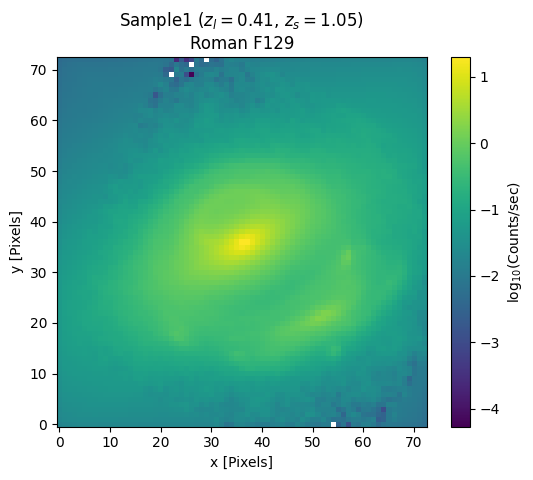

Shape: (73, 73)
Flux: 1808.716881442519
Maggies: 5.365494038617282e-08


In [6]:
# sample = SampleGG()
sample = Sample1()
roman_instrument = Roman()
synth = SyntheticImage(sample, band=band, instrument=roman_instrument, fov_arcsec=8.03, kwargs_psf=kwargs_psf)
synth.plot()

flux = synth.get_flux()
maggies = synth.get_maggies()

print(f'Shape: {synth.data.shape}')
print(f'Flux: {flux}')
print(f'Maggies: {maggies}')